# Credit Card Fraud Detection

## Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning.

The dataset contains transaction-related features along with a target variable, `Class`, where:
- `0` represents a legitimate transaction
- `1` represents a fraudulent transaction

The main objective is to build and evaluate machine learning models that can identify fraudulent transactions while handling the highly imbalanced nature of the dataset.

## Import Required Libraries

We import the libraries required for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [36]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The complete credit card transaction dataset is loaded for analysis and model development.


In [37]:

credit_card_data = pd.read_csv("creditcard.csv")

In [38]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Credit Card Details are very sensitive details, thus should not be exposed . Thus, the dataset provider has converted all the features through principal component analysis method, converting all the features into these numerical values. Here , Amount Column is in USD and Class Column is composed of 2 labels (0 for Legit Transaction and 1 for Fraudulent Transaction). Time is in seconds.

In [39]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [40]:
credit_card_data.shape

(284807, 31)

## Exploratory Data Analysis

We examine the structure, statistical properties, and data quality of the dataset before building the machine learning models.

In [41]:
# Dataset information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [42]:
# Checking the number of missing values in each column

credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

This shows that we dont have any missing values.


In [43]:
# Distribution of legit transactions and fraudulent transactions
credit_card_data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

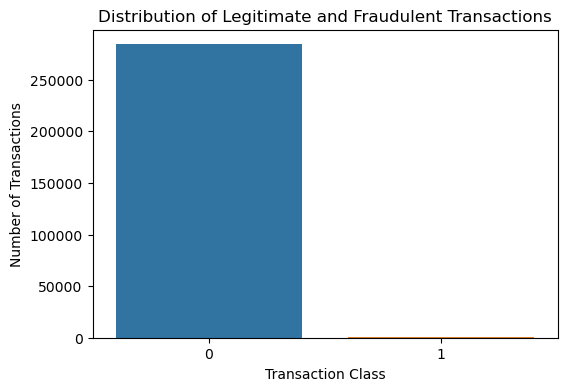

In [44]:
# Visualize the class imbalance.
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Class",
    data=credit_card_data
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [45]:
class_distribution = credit_card_data["Class"].value_counts(
    normalize=True
) * 100

print(class_distribution)

0    99.827251
1     0.172749
Name: Class, dtype: float64


## Analyze Class Distribution

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of total transactions.

Understanding this imbalance is important because accuracy alone may not provide a reliable measure of fraud detection performance.

## Separate Features and Target

The dataset is divided into:
- Features (`X`): transaction attributes used by the models
- Target (`Y`): the `Class` variable indicating whether a transaction is legitimate or fraudulent

In [46]:

X = credit_card_data.drop("Class", axis=1)

Y = credit_card_data["Class"]

In [47]:
print("Features:", X.shape)
print("Target:", Y.shape)

Features: (284807, 30)
Target: (284807,)


## Split the Dataset

The dataset is divided into training and testing sets using stratified sampling.

The split is performed before addressing class imbalance so that the test set retains the original real-world class distribution.

In [48]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [49]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 30)
Testing set: (56962, 30)


In [50]:
print("\nTraining class distribution:")
print(Y_train.value_counts())

print("\nTesting class distribution:")
print(Y_test.value_counts())


Training class distribution:
0    227451
1       394
Name: Class, dtype: int64

Testing class distribution:
0    56864
1       98
Name: Class, dtype: int64


## Scale the Features

Feature scaling is applied to ensure that numerical features are on comparable scales.

The scaler is fitted only on the training data and then applied to both the training and testing data.

In [51]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression is used as the baseline classification model.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used to give greater importance to the minority fraud class.

In [52]:

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [53]:
# Train
logistic_model.fit(
    X_train_scaled,
    Y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [54]:
# Predict
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

## Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

A confusion matrix is also used to understand the number of correctly and incorrectly classified transactions.

In [55]:

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [56]:
print("Accuracy:",
      accuracy_score(Y_test, y_pred))

print("Precision:",
      precision_score(Y_test, y_pred))

print("Recall:",
      recall_score(Y_test, y_pred))

print("F1 Score:",
      f1_score(Y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(Y_test, y_prob))

print("PR-AUC:",
      average_precision_score(Y_test, y_prob))

Accuracy: 0.9755451002422668
Precision: 0.061016949152542375
Recall: 0.9183673469387755
F1 Score: 0.11443102352193261
ROC-AUC: 0.9720881652464024
PR-AUC: 0.718934567134695


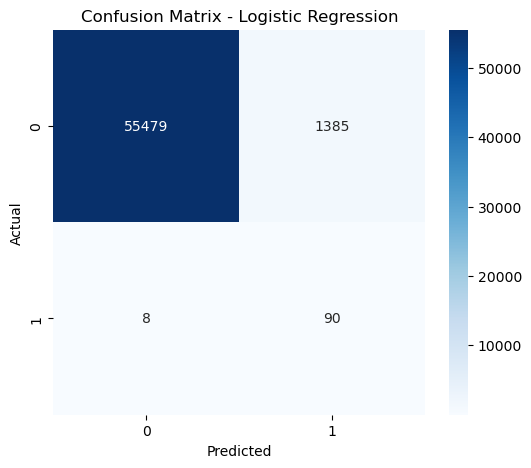

In [57]:
# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Random Forest Classifier

Random Forest is used as a second classification model to compare its performance with Logistic Regression.

Since the dataset is highly imbalanced, class weights are used to give more importance to fraudulent transactions.

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [59]:
# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression so that the two models can be compared consistently.

A confusion matrix is also analyzed to examine false positives and false negatives.

In [60]:

print("Random Forest Results")
print("---------------------")

print("Accuracy:", accuracy_score(Y_test, rf_pred))
print("Precision:", precision_score(Y_test, rf_pred))
print("Recall:", recall_score(Y_test, rf_pred))
print("F1 Score:", f1_score(Y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(Y_test, rf_prob))
print("PR-AUC:", average_precision_score(Y_test, rf_prob))


Random Forest Results
---------------------
Accuracy: 0.9995084442259752
Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1 Score: 0.839080459770115
ROC-AUC: 0.952908497036969
PR-AUC: 0.8541999432510914


In [61]:
# Classification report
print(classification_report(Y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



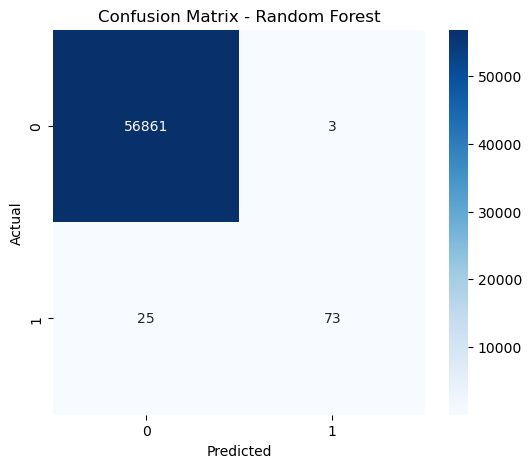

In [62]:
# Confusion Matrix
cm_rf = confusion_matrix(Y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Model Comparison

We compare Logistic Regression and Random Forest using multiple evaluation metrics.

Since the dataset is highly imbalanced, precision, recall, F1-score, ROC-AUC and PR-AUC are considered alongside accuracy.

In [63]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred),
        accuracy_score(Y_test, rf_pred)
    ],
    "Precision": [
        precision_score(Y_test, y_pred),
        precision_score(Y_test, rf_pred)
    ],
    "Recall": [
        recall_score(Y_test, y_pred),
        recall_score(Y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(Y_test, y_pred),
        f1_score(Y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(Y_test, y_prob),
        roc_auc_score(Y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(Y_test, y_prob),
        average_precision_score(Y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.975545,0.061017,0.918367,0.114431,0.972088,0.718935
1,Random Forest,0.999508,0.960526,0.744898,0.839080,0.952908,0.854200


## Cross-Validation

Stratified cross-validation is used to obtain a more reliable estimate of model performance across different subsets of the training data.

This helps reduce the possibility that the evaluation depends heavily on a single train-test split.

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [65]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_results = cross_validate(
    logistic_model,
    X_train_scaled,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [66]:
print("Logistic Regression - 5-Fold Cross-Validation")

print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1 Score:", cv_results["test_f1"].mean())
print("Mean ROC-AUC:", cv_results["test_roc_auc"].mean())
print("Mean PR-AUC:", cv_results["test_pr_auc"].mean())

Logistic Regression - 5-Fold Cross-Validation
Mean Precision: 0.06288821277686067
Mean Recall: 0.9137617656604998
Mean F1 Score: 0.11763269446624743
Mean ROC-AUC: 0.9825082702970324
Mean PR-AUC: 0.7567515886719829


## Cross-Validation with Pipeline

A Pipeline combines feature scaling and model training into a single workflow.

This ensures that the scaler is fitted independently within each cross-validation fold, preventing information from the validation fold from influencing preprocessing.


In [67]:
from sklearn.pipeline import Pipeline

In [68]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [69]:
cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [70]:
print("Logistic Regression - 5-Fold Cross-Validation")

print("Mean Precision:", cv_results["test_precision"].mean())
print("Mean Recall:", cv_results["test_recall"].mean())
print("Mean F1 Score:", cv_results["test_f1"].mean())
print("Mean ROC-AUC:", cv_results["test_roc_auc"].mean())
print("Mean PR-AUC:", cv_results["test_pr_auc"].mean())

Logistic Regression - 5-Fold Cross-Validation
Mean Precision: 0.06291343164872601
Mean Recall: 0.9137617656604998
Mean F1 Score: 0.11767635748506937
Mean ROC-AUC: 0.9825083823148774
Mean PR-AUC: 0.7567496504068455


## Random Forest Cross-Validation

Stratified 5-fold cross-validation is used to evaluate the consistency of the Random Forest model across different subsets of the training data.

The same evaluation metrics are used to allow comparison with Logistic Regression.

In [71]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [72]:
rf_cv_results = cross_validate(
    rf_pipeline,
    X_train,
    Y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [73]:
print("Random Forest - 5-Fold Cross-Validation")

print("Mean Precision:", rf_cv_results["test_precision"].mean())
print("Mean Recall:", rf_cv_results["test_recall"].mean())
print("Mean F1 Score:", rf_cv_results["test_f1"].mean())
print("Mean ROC-AUC:", rf_cv_results["test_roc_auc"].mean())
print("Mean PR-AUC:", rf_cv_results["test_pr_auc"].mean())


Random Forest - 5-Fold Cross-Validation
Mean Precision: 0.9520659907032858
Mean Recall: 0.741123012009088
Mean F1 Score: 0.8328034474598602
Mean ROC-AUC: 0.9516391104165856
Mean PR-AUC: 0.8393638836728836


## Cross-Validation Model Comparison

The cross-validation results of Logistic Regression and Random Forest are compared using precision, recall, F1-score, ROC-AUC, and PR-AUC.

This comparison helps assess the consistency of both models across multiple training and validation folds.

In [74]:
cv_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        cv_results["test_precision"].mean(),
        rf_cv_results["test_precision"].mean()
    ],
    "Recall": [
        cv_results["test_recall"].mean(),
        rf_cv_results["test_recall"].mean()
    ],
    "F1 Score": [
        cv_results["test_f1"].mean(),
        rf_cv_results["test_f1"].mean()
    ],
    "ROC-AUC": [
        cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_roc_auc"].mean()
    ],
    "PR-AUC": [
        cv_results["test_pr_auc"].mean(),
        rf_cv_results["test_pr_auc"].mean()
    ]
})

cv_comparison

,Model,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.062913,0.913762,0.117676,0.982508,0.756750
1,Random Forest,0.952066,0.741123,0.832803,0.951639,0.839364


## Feature Importance

Feature importance is used to understand which transaction features contribute most to the Random Forest's predictions.

This helps provide interpretability and gives insight into which features have the greatest influence on fraud classification.

In [75]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

V14    0.179857
V10    0.115442
V12    0.096206
V4     0.095646
V17    0.095113
V3     0.068669
V11    0.056112
V16    0.040303
V2     0.036265
V9     0.026888
dtype: float64

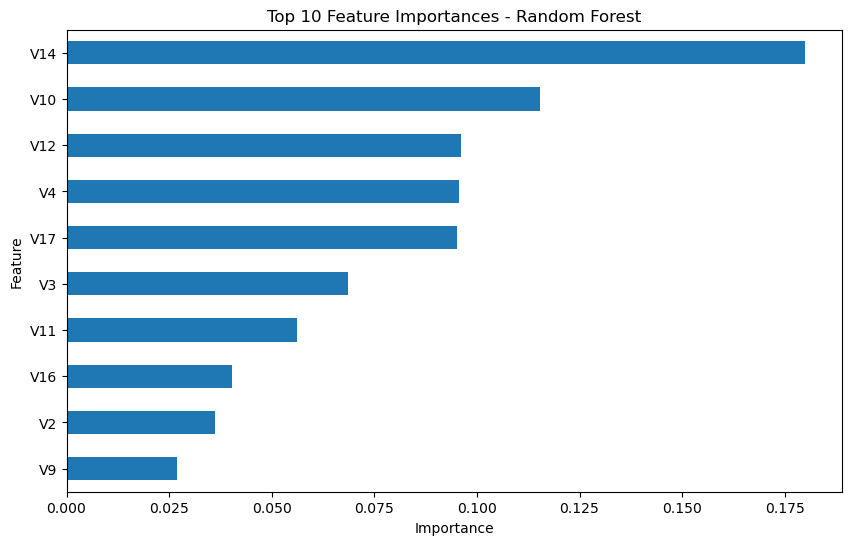

In [76]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve shows the relationship between the true positive rate and false positive rate at different classification thresholds.

The Area Under the ROC Curve (ROC-AUC) provides a summary of the model's ability to distinguish between legitimate and fraudulent transactions.

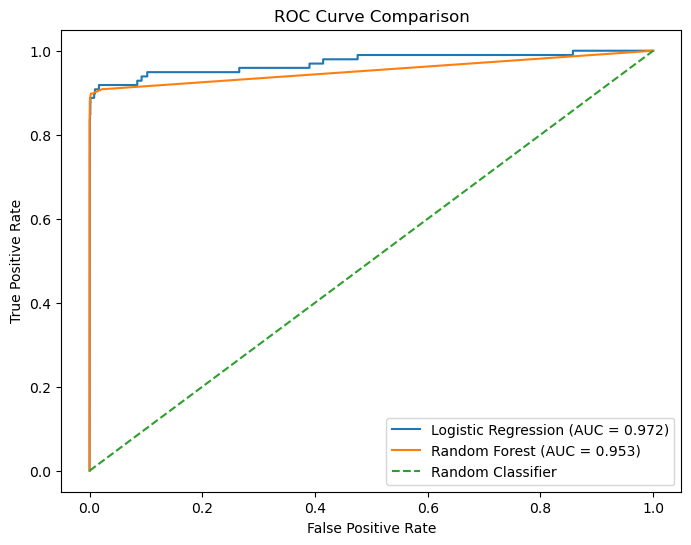

In [77]:
# Calculate ROC curve for both models

lr_fpr, lr_tpr, _ = roc_curve(Y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(Y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(Y_test, y_prob):.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(Y_test, rf_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Precision-Recall Curve Comparison

The Precision-Recall curve shows the relationship between precision and recall at different classification thresholds.

It is particularly useful for imbalanced classification problems because it focuses on the performance of the model on the positive class, which represents fraudulent transactions in this project.

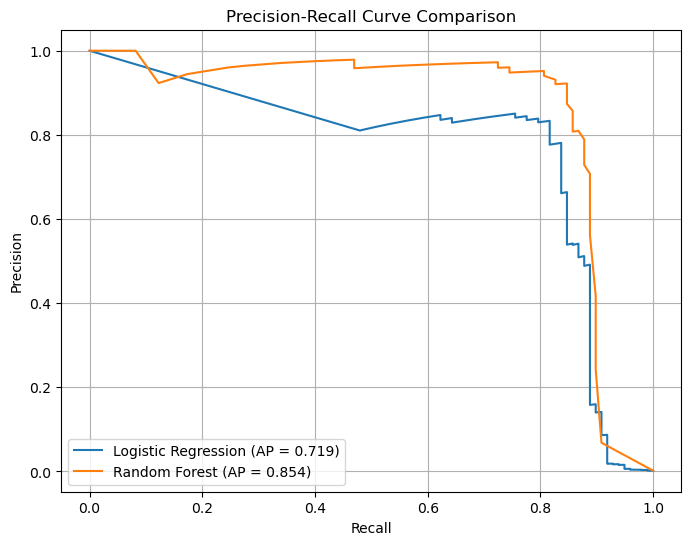

In [78]:
# Calculate Precision-Recall curves

lr_precision, lr_recall, _ = precision_recall_curve(Y_test, y_prob)
rf_precision, rf_recall, _ = precision_recall_curve(Y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_recall,
    lr_precision,
    label=f"Logistic Regression (AP = {average_precision_score(Y_test, y_prob):.3f})"
)

plt.plot(
    rf_recall,
    rf_precision,
    label=f"Random Forest (AP = {average_precision_score(Y_test, rf_prob):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()
plt.show()

## Threshold Tuning

The default classification threshold of 0.5 is not always optimal for fraud detection.

Different thresholds can change the balance between precision and recall. Threshold tuning helps identify a threshold that provides a suitable balance for the intended fraud detection application.

In [79]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    rf_threshold_pred = (rf_prob >= threshold).astype(int)

    precision = precision_score(Y_test, rf_threshold_pred)
    recall = recall_score(Y_test, rf_threshold_pred)
    f1 = f1_score(Y_test, rf_threshold_pred)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.1,0.741379,0.877551,0.803738
1,0.2,0.857143,0.857143,0.857143
2,0.3,0.922222,0.846939,0.882979
3,0.4,0.951807,0.806122,0.872928
4,0.5,0.960526,0.744898,0.839080
5,0.6,0.972603,0.724490,0.830409
6,0.7,0.970588,0.673469,0.795181
7,0.8,0.966667,0.591837,0.734177
8,0.9,0.958333,0.469388,0.630137


## Threshold Performance Analysis

The effect of different classification thresholds on precision, recall, and F1-score is visualized to understand the trade-off between detecting more fraudulent transactions and reducing false positives.

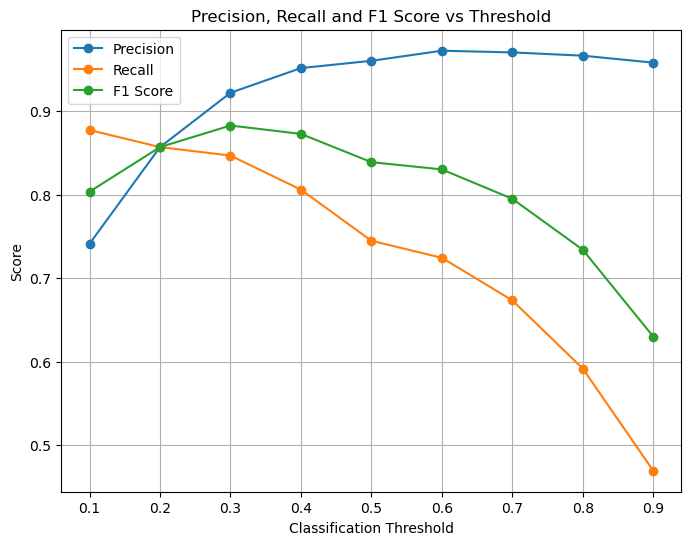

In [80]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score vs Threshold")
plt.legend()
plt.grid()
plt.show()

## Select Threshold Based on F1 Score

The threshold that produces the highest F1-score among the tested thresholds is identified programmatically.

This provides a reproducible way to select a threshold based on the balance between precision and recall.

In [81]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Threshold with highest F1 Score:")
print(best_threshold_row)

Threshold with highest F1 Score:
Threshold    0.300000
Precision    0.922222
Recall       0.846939
F1 Score     0.882979
Name: 2, dtype: float64


## Random Forest with Tuned Threshold

The selected threshold is applied to the Random Forest probability predictions.

Instead of using the default threshold of 0.5, a threshold of 0.3 is used to classify transactions as fraudulent when the predicted fraud probability is at least 0.3.

In [82]:
# Apply the tuned threshold

selected_threshold = 0.30

rf_tuned_pred = (rf_prob >= selected_threshold).astype(int)

print("Random Forest Performance with Tuned Threshold")
print("Precision:", precision_score(Y_test, rf_tuned_pred))
print("Recall:", recall_score(Y_test, rf_tuned_pred))
print("F1 Score:", f1_score(Y_test, rf_tuned_pred))

Random Forest Performance with Tuned Threshold
Precision: 0.9222222222222223
Recall: 0.8469387755102041
F1 Score: 0.8829787234042554


## Confusion Matrix with Tuned Threshold

The confusion matrix is used to examine the classification results of the Random Forest after applying the tuned threshold of 0.3.

It shows the number of legitimate and fraudulent transactions that were correctly or incorrectly classified.

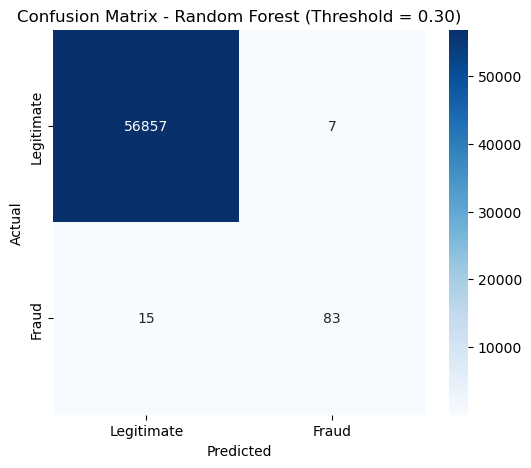

In [83]:
cm_tuned = confusion_matrix(Y_test, rf_tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Threshold = 0.30)")
plt.show()

## Final Model Summary

The Random Forest classifier was evaluated using multiple metrics because the dataset is highly imbalanced.

After comparing different classification thresholds, a threshold of 0.30 produced the highest F1-score among the tested thresholds.

At this threshold, the Random Forest achieved:

- Precision: 92.22%
- Recall: 84.69%
- F1 Score: 88.30%

The tuned threshold provides a different precision-recall balance compared with the default threshold of 0.50.

## Save the Trained Model

The trained Random Forest model is saved to a file using Joblib.

Saving the model allows it to be reused later without retraining it from the beginning. This is useful when deploying the model in a web application such as a Streamlit app.

In [84]:
import joblib

In [85]:
joblib.dump(rf_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

## Save the Classification Threshold

The tuned classification threshold is saved separately so that the same threshold can be used when the model is deployed.

In [86]:
joblib.dump(selected_threshold, "fraud_threshold.pkl")

['fraud_threshold.pkl']